In [ ]:
import pandas as pd
import gdown

file_id = "1plXZ4pwcNjzU6YCQgU1NjhJs74XHYnfJ"

nombre_archivo_salida = "dataset_har.csv"

gdown.download(id=file_id, output=nombre_archivo_salida, quiet=False)

try:
    df = pd.read_csv(nombre_archivo_salida)
    print(f"Dimensiones iniciales del dataset: {df.shape}")
except FileNotFoundError:
    print("Error al descargar archivo")

Downloading...
From (original): https://drive.google.com/uc?id=1plXZ4pwcNjzU6YCQgU1NjhJs74XHYnfJ
From (redirected): https://drive.google.com/uc?id=1plXZ4pwcNjzU6YCQgU1NjhJs74XHYnfJ&confirm=t&uuid=50e27007-af3e-428c-8661-b6f15efd7e23
To: /content/dataset_har.csv
100%|██████████| 433M/433M [00:04<00:00, 92.2MB/s]


Dimensiones iniciales del dataset: (1140000, 48)


# Escalamiento

In [ ]:
print(df.columns)

Index(['activity', 'subject', 'time', 'T_xacc', 'T_yacc', 'T_zacc', 'T_xgyro',
       'T_ygyro', 'T_zgyro', 'T_xmag', 'T_ymag', 'T_zmag', 'RA_xacc',
       'RA_yacc', 'RA_zacc', 'RA_xgyro', 'RA_ygyro', 'RA_zgyro', 'RA_xmag',
       'RA_ymag', 'RA_zmag', 'LA_xacc', 'LA_yacc', 'LA_zacc', 'LA_xgyro',
       'LA_ygyro', 'LA_zgyro', 'LA_xmag', 'LA_ymag', 'LA_zmag', 'RL_xacc',
       'RL_yacc', 'RL_zacc', 'RL_xgyro', 'RL_ygyro', 'RL_zgyro', 'RL_xmag',
       'RL_ymag', 'RL_zmag', 'LL_xacc', 'LL_yacc', 'LL_zacc', 'LL_xgyro',
       'LL_ygyro', 'LL_zgyro', 'LL_xmag', 'LL_ymag', 'LL_zmag'],
      dtype='object')


In [ ]:
from sklearn.preprocessing import MinMaxScaler

separamos las columnas a escalar
X = df.columns[3:]


scaler = MinMaxScaler()
df[X] = scaler.fit_transform(df[X])
df

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

GRUPOS = ['T', 'RA', 'LA', 'RL', 'LL']

NOMBRES_GRUPO = {
    'T': 'Tronco', 'RA': 'Mano Derecha', 'LA': 'Mano Izquierda',
    'RL': 'Pierna Derecha', 'LL': 'Pierna Izquierda'
}

SUFIJOS_TIPO = {
    'acc':  ['xacc',  'yacc',  'zacc'],
    'gyro': ['xgyro', 'ygyro', 'zgyro'],
    'mag':  ['xmag',  'ymag',  'zmag']
}

NOMBRES_TIPO = {
    'acc': 'Acelerómetro', 'gyro': 'Giroscopio', 'mag': 'Magnetómetro'
}

UNIDADES_TIPO = {
    'acc': 'Acceleration (sensor units)',
    'gyro': 'Angular velocity (sensor units)',
    'mag': 'Magnetic field (sensor units)'
}


def histogramas_por_tipo(df, tipo, bins=50):
    """
    Genera una figura de 5x3 con histogramas para los 15 sensores de un tipo dado.

    Parámetros
    ----------
    df   : DataFrame con los datos
    tipo : str - 'acc', 'gyro' o 'mag'
    bins : int - número de bins del histograma (default 50)
    """
    if tipo not in SUFIJOS_TIPO:
        raise ValueError(f"Tipo '{tipo}' no válido. Opciones: {list(SUFIJOS_TIPO.keys())}")

    sufijos = SUFIJOS_TIPO[tipo]
    unidad = UNIDADES_TIPO[tipo]
    colors = plt.cm.viridis(np.linspace(0.1, 0.9, len(GRUPOS)))

    fig, axes = plt.subplots(nrows=len(GRUPOS), ncols=3, figsize=(18, 16), sharey=False)
    fig.suptitle(f"Histogramas — {NOMBRES_TIPO[tipo]}", fontsize=15, fontweight='bold')

    for i, grupo in enumerate(GRUPOS):
        for j, sufijo in enumerate(sufijos):
            ax = axes[i][j]
            columna = f"{grupo}_{sufijo}"

            ax.hist(df[columna].dropna(), bins=bins, color=colors[i], alpha=0.8, edgecolor='white', linewidth=0.3)

            ax.set_title(columna, fontsize=9, fontweight='bold')
            ax.set_xlabel(unidad, fontsize=7)
            ax.set_ylabel('Frecuencia', fontsize=7)
            ax.tick_params(labelsize=7)
            ax.grid(True, linestyle='--', alpha=0.3)

        axes[i][0].set_ylabel(f"{NOMBRES_GRUPO[grupo]}\nFrecuencia", fontsize=7, fontweight='bold')

    plt.tight_layout()
    plt.show()

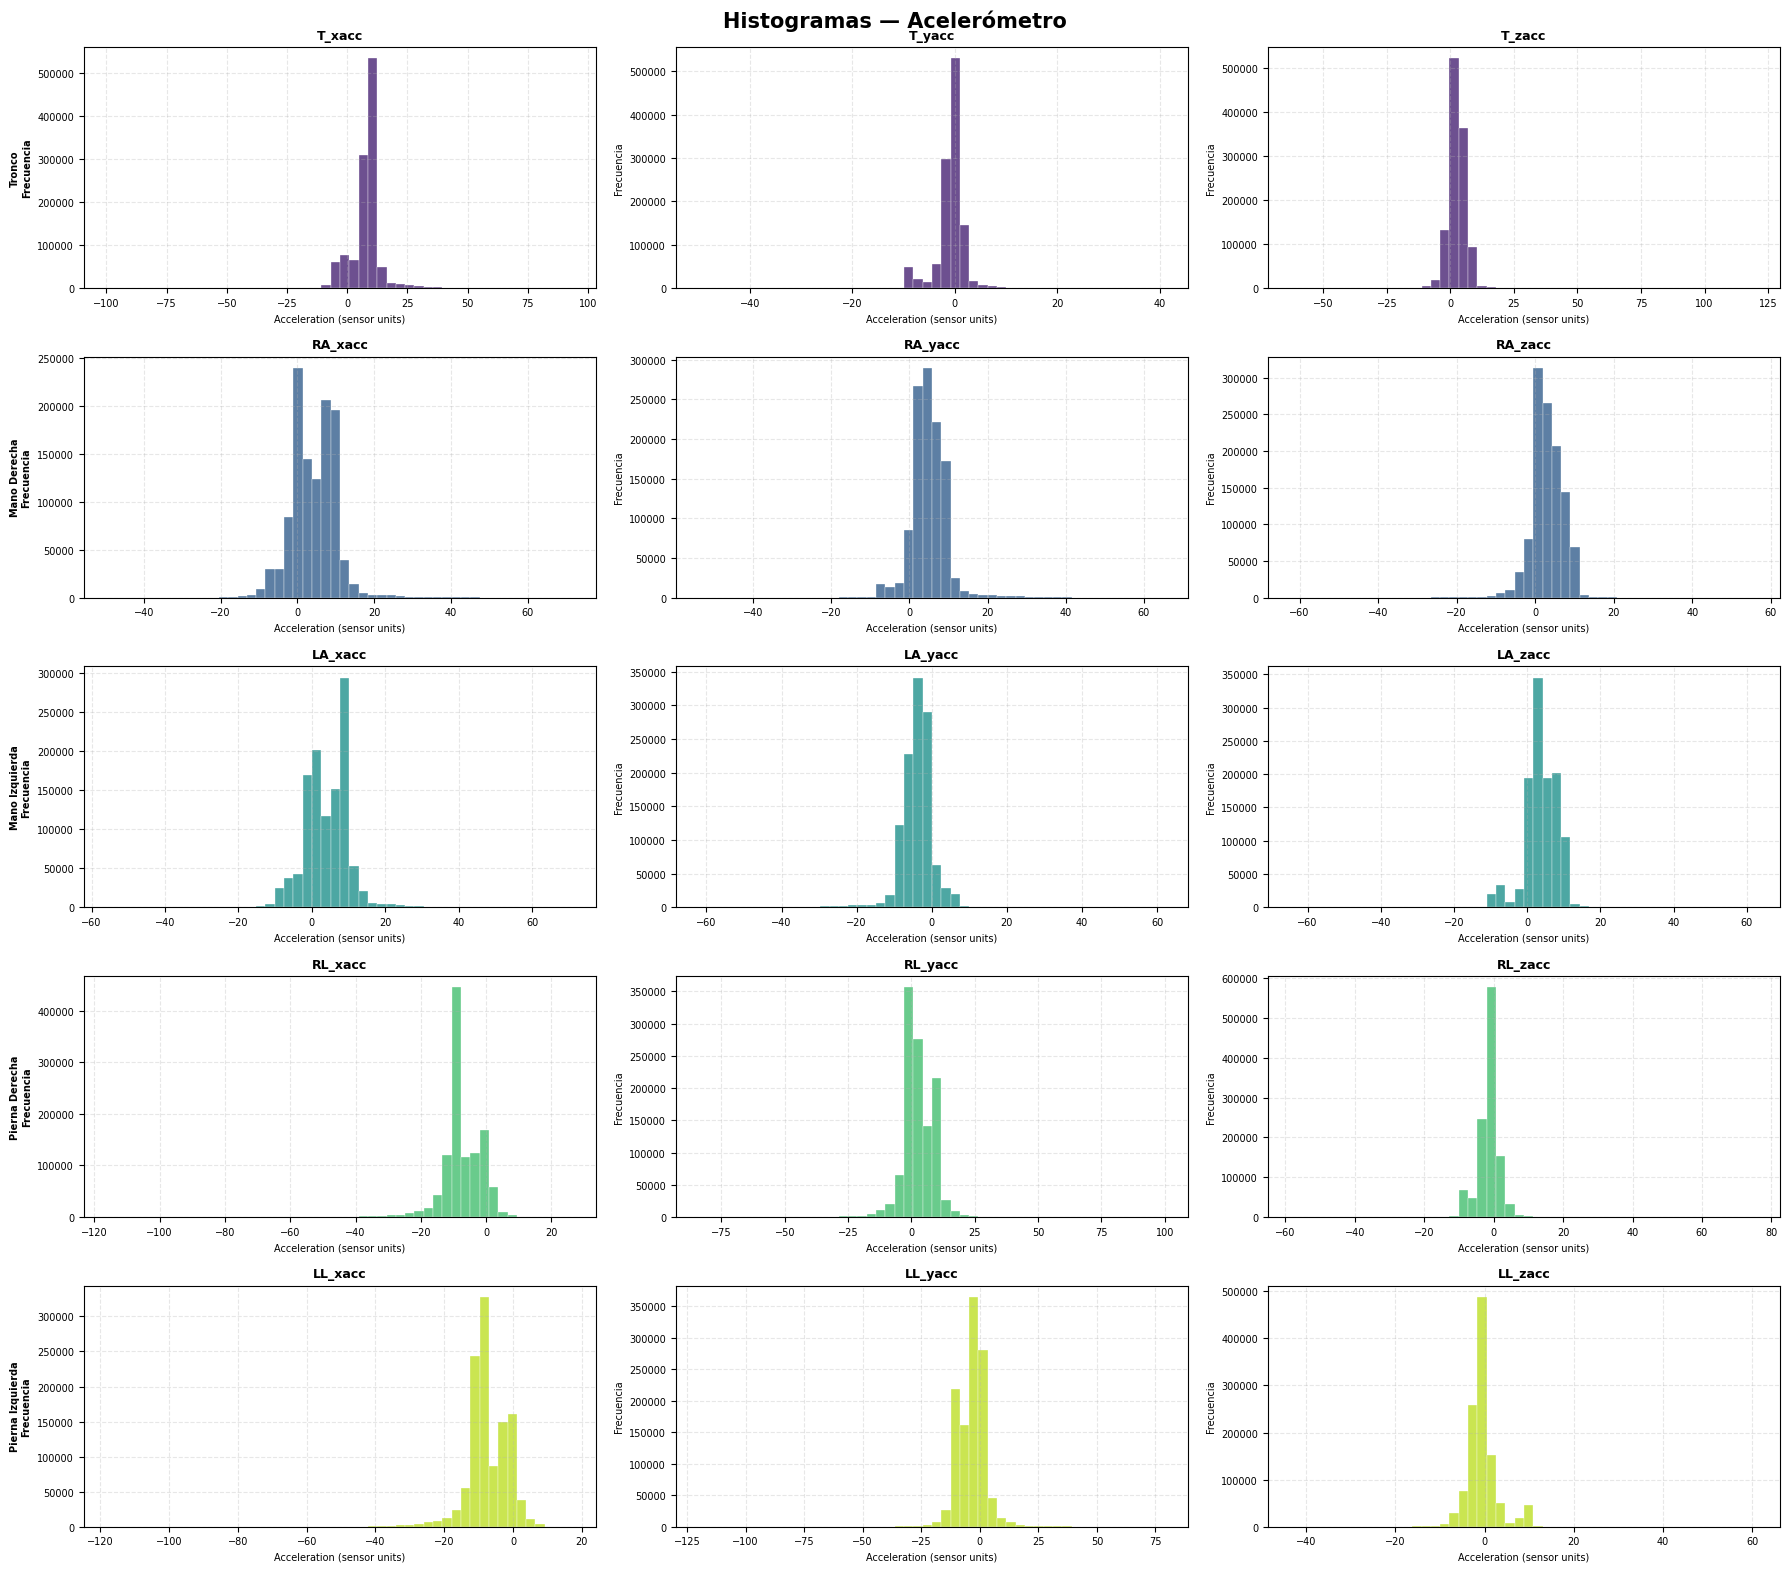

In [ ]:
histogramas_por_tipo(df, 'acc')